In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score


<h1> 1) Data exploration </h1>

In [68]:
df = pd.read_csv("BTC_daily_historical.csv")

In [69]:
print(df.describe()) 
print(50*"-")
print(df.dtypes)
print(50*"-")
print(df.isna().sum())

               open         close        volume          high           low  \
count   3987.000000   3987.000000  3.987000e+03   3987.000000   3987.000000   
mean   17717.745815  17740.647510  1.700194e+10  18119.554536  17300.833438   
std    20784.761185  20818.644318  1.964630e+10  21251.079054  20312.065879   
min      176.897003    178.102997  2.857830e+06    211.731003    171.509995   
25%      705.082001    705.037506  9.604215e+07    716.576019    697.131012   
50%     8549.470909   8562.454050  1.228464e+10   8726.796760   8273.572887   
75%    29041.107415  29060.921365  2.795070e+10  29442.301440  28663.461045   
max    99006.742270  98997.662080  3.509680e+11  99655.501080  97232.893120   

         market cap  
count  3.987000e+03  
mean   3.368993e+11  
std    4.056019e+11  
min    2.444379e+09  
25%    1.048527e+10  
50%    1.499140e+11  
75%    5.585695e+11  
max    1.958950e+12  
--------------------------------------------------
date           object
open          flo

In [70]:
df["date"] = pd.to_datetime(df["date"])

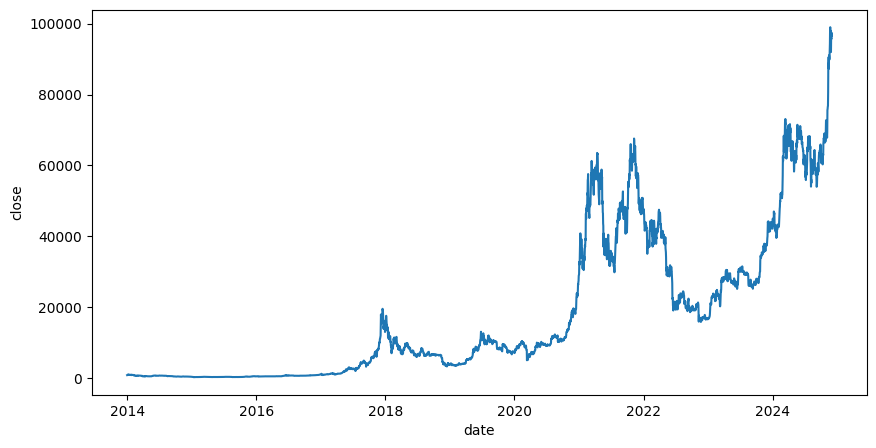

In [71]:
fig = plt.figure(figsize=(10,5))

sns.lineplot(data=df, x="date", y="close")
plt.show()

In [72]:
df["date"].max()

Timestamp('2024-11-30 00:00:00+0000', tz='UTC')

<h1> 2) Predictors </h1>

In [73]:
df['Year_Week'] = df['date'].dt.strftime('%Y-%W')

first_week_day = df.groupby("Year_Week")["date"].idxmin() 
last_week_day = df.groupby("Year_Week")["date"].idxmax()

In [74]:
MCAP = df.loc[last_week_day]
df["MCAP"] = np.log(MCAP["market cap"])

df["MCAP"] = df.groupby("Year_Week")["MCAP"].transform(lambda x: x.fillna(method="ffill").fillna(method="bfill"))    


/var/folders/xt/qp4h10d92h76_sfj0rh4m3v00000gn/T/ipykernel_12558/4214954205.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["MCAP"] = df.groupby("Year_Week")["MCAP"].transform(lambda x: x.fillna(method="ffill").fillna(method="bfill"))


In [75]:
MCAP["year"] = MCAP["date"].dt.strftime("%Y")
test = MCAP.groupby("year").count()

In [76]:
PRC = df.loc[last_week_day]
df["PRC"] = np.log(PRC["close"])
df["PRC"] = df.groupby("Year_Week")["PRC"].transform(lambda x: x.fillna(method="ffill").fillna(method="bfill"))    

/var/folders/xt/qp4h10d92h76_sfj0rh4m3v00000gn/T/ipykernel_12558/1108071729.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["PRC"] = df.groupby("Year_Week")["PRC"].transform(lambda x: x.fillna(method="ffill").fillna(method="bfill"))


In [77]:
max_price_week = df.groupby("Year_Week")["close"].idxmax()
df["MAXDPRC"] = df.loc[max_price_week, "close"]
df["MAXDPRC"] = df.groupby("Year_Week")["MAXDPRC"].transform(lambda x: x.fillna(method="ffill").fillna(method="bfill"))    


/var/folders/xt/qp4h10d92h76_sfj0rh4m3v00000gn/T/ipykernel_12558/439710787.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["MAXDPRC"] = df.groupby("Year_Week")["MAXDPRC"].transform(lambda x: x.fillna(method="ffill").fillna(method="bfill"))


In [67]:
def get_past_n_week_return(n, row):
    current_index = row.name
    past_index = current_index - n
    try: 
        ret = df.loc[current_index, "close"] - df.loc[past_index, "close"]
    except: 
        ret = np.nan

    return ret

In [303]:
df["past_one_week_return"] = df.apply(lambda x: get_past_n_week_return(6, x), axis=1)
df["past_two_week_return"] = df.apply(lambda x: get_past_n_week_return(13, x), axis=1)

In [94]:
#more efficient way

df["r_1"] = df["close"].diff(6)
df["r_2"] = df["close"].diff(13)
df["r_3"] = df["close"].diff(20)
df["r_4"] = df["close"].diff(27)
df["r_4_1"] = df["r_4"] - df["r_1"]
df["rel_daily_return"] = df["close"].diff(-1) / df["close"]

In [81]:
PRCVOL = np.log(df.groupby("Year_Week")["volume"].mean()) 
df = pd.merge(df, PRCVOL.rename("PRCVOL"), left_on="Year_Week", right_index=True, how="left")

 

In [ ]:
STDPRCVOL = np.log(df.groupby("Year_Week")["volume"].std()) 
df = pd.merge(df, STDPRCVOL.rename("STDPRCVOL"), left_on="Year_Week", right_index=True, how="left")


In [87]:
abs_avg_daily_return = df["rel_abs_daily_return"].abs().groupby(df["Year_Week"]).mean()

DAMIHUD = abs_avg_daily_return / PRCVOL

df = pd.merge(df, DAMIHUD.rename("DAMIHUD"), left_on="Year_Week", right_index=True, how="left")

<h1> 3) Seven Day Return </h1>

In [88]:
df["seven_day_return"] = (df["close"].diff(-6)) / df["close"]

<h1> 4) Log Reg, Random Forest, SVM </h1>

In [101]:
df_price_vol = df.copy(deep=True)
df_price_vol = df_price_vol[["open", "close", "high", "low", "volume", "seven_day_return"]]
df_price_vol.dropna(inplace=True)
y = df_price_vol["seven_day_return"]
X = df_price_vol.drop("seven_day_return", axis=1)

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [102]:
lin_reg = LinearRegression()

lin_reg.fit(X_train, y_train)
y_pred = lin_reg.predict(X_test)
print(r2_score(y_test, y_pred))


-0.014059699525415414


In [103]:
rf = RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print(r2_score(y_test, y_pred))

0.06671354074801805


In [104]:
svr = SVR()
svr.fit(X_train, y_train)
y_pred = svr.predict(X_test)
print(r2_score(y_test, y_pred))

-0.03070268967359091


<h1> 5) Prediction based on Factors

In [105]:
df_factors = df[["date", "MCAP", "PRC", "MAXDPRC", "r_1", "r_2", "r_3", "r_4", "r_4_1", "PRCVOL", "STDPRCVOL", "DAMIHUD", "seven_day_return"]]
df_factors.dropna(inplace=True)
y = df_factors["seven_day_return"]
X = df_factors.drop("seven_day_return", axis=1)


/var/folders/xt/qp4h10d92h76_sfj0rh4m3v00000gn/T/ipykernel_12558/1746261825.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_factors.dropna(inplace=True)


In [156]:
sample = df_factors[df_factors["date"] <= "2022-12-31 00:00:00+00:00"]
out_of_sample = df[df["date"]>"2022-12-31 00:00:00+00:00"]

sample.drop("date", axis=1, inplace=True)
sample.dropna(inplace=True)
out_of_sample.drop("date", axis=1, inplace=True)
out_of_sample.dropna(inplace=True)
y = sample["seven_day_return"]
X = sample.drop("seven_day_return", axis=1)

print(X.columns)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print(r2_score(y_test, y_pred))

/var/folders/xt/qp4h10d92h76_sfj0rh4m3v00000gn/T/ipykernel_12558/255980474.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample.drop("date", axis=1, inplace=True)
/var/folders/xt/qp4h10d92h76_sfj0rh4m3v00000gn/T/ipykernel_12558/255980474.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample.dropna(inplace=True)
/var/folders/xt/qp4h10d92h76_sfj0rh4m3v00000gn/T/ipykernel_12558/255980474.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-vers

Index(['MCAP', 'PRC', 'MAXDPRC', 'r_1', 'r_2', 'r_3', 'r_4', 'r_4_1', 'PRCVOL',
       'STDPRCVOL', 'DAMIHUD'],
      dtype='object')
0.5569726430009302


In [184]:
def buy(btc, cash, close): 
    if not cash == 0: 
        btc = cash / close 
        cash = 0
    return btc, cash 

def sell(btc, cash, close): 
    if not btc == 0: 
        cash = btc * close
        btc = 0
    return btc, cash 

In [ ]:
row = out_of_sample.reset_index().loc[0, ['MCAP', 'PRC', 'MAXDPRC', 'r_1', 'r_2', 'r_3', 'r_4', 'r_4_1', 'PRCVOL','STDPRCVOL', 'DAMIHUD']]
pred = rf.predict(pd.DataFrame(row).transpose())
print(row)
print(pred)

"""
    if prediction >= 0:
        btc, cash = buy(btc, cash, row["close"])
    else:
        btc, cash = sell(btc, cash, row["close"])"""

MCAP           26.519673
PRC             9.746316
MAXDPRC      17091.14445
r_1            -28.70262
r_2           -217.83385
r_3          -1092.84748
r_4           -401.03235
r_4_1         -372.32973
PRCVOL         23.277306
STDPRCVOL      21.963897
DAMIHUD         0.000211
Name: 0, dtype: object
[-0.00954916]


'\n    if prediction >= 0:\n        btc, cash = buy(btc, cash, row["close"])\n    else:\n        btc, cash = sell(btc, cash, row["close"])'

In [ ]:
df_factors = df.copy(deep=True)
df_factors = pd.merge(df_factors, MCAP[["date", "MCAP"]], on="date", how="left")
df_factors["MCAP"] = df_factors.groupby("Year_Week")["MCAP"].transform(lambda x: x.fillna(method="ffill").fillna(method="bfill"))    

/var/folders/xt/qp4h10d92h76_sfj0rh4m3v00000gn/T/ipykernel_4788/1215920404.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_factors["MCAP"] = df_factors.groupby("Year_Week")["MCAP"].transform(lambda x: x.fillna(method="ffill").fillna(method="bfill"))


In [196]:
cash = 100000
btc = 0

track = []


for index, row in out_of_sample.iterrows():
    features = row[['MCAP', 'PRC', 'MAXDPRC', 'r_1', 'r_2', 'r_3', 'r_4', 'r_4_1', 'PRCVOL','STDPRCVOL', 'DAMIHUD']]
    prediction = rf.predict(pd.DataFrame(features).transpose())[0]
    if prediction >= 0:
        btc, cash = buy(btc, cash, row["close"])
    else:
        btc, cash = sell(btc, cash, row["close"])
    if cash == 0: 
        track.append(btc*row["close"])
    else: 
        track.append(cash)

In [193]:
start_price = out_of_sample.iloc[0]["close"]
end_price = out_of_sample.iloc[-1]["close"]

buy_and_hold_return = (100000 / start_price) * end_price
buy_and_hold_return

587314.5526373723

In [194]:
print("Final Result: ")
print(50*"-")
print("with prediction strategy")
print(50*"-")
print("Cahs: ", cash)
print("BTC: ", btc)
print("BTC value: ", btc * out_of_sample.iloc[-1]["close"])
print(50*"-")
print("with buy and hold strategy")
print(50*"-")
print(buy_and_hold_return)


Final Result: 
--------------------------------------------------
with prediction strategy
--------------------------------------------------
Cahs:  0
BTC:  2.1286830386840347
BTC value:  208640.35812773157
--------------------------------------------------
with buy and hold strategy
--------------------------------------------------
587314.5526373723


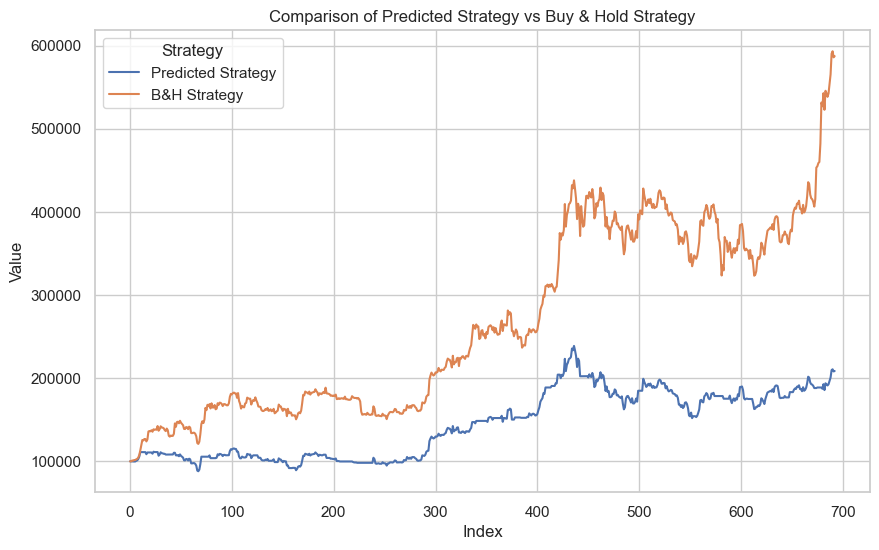

In [207]:
pred_strat = pd.DataFrame({"Index": range(len(track)), "Value": track, "Strategy": "Predicted Strategy"})
buy_and_hold_strat = pd.DataFrame({"Index": range(len(out_of_sample)),
                                   "Value":out_of_sample["close"] * (100000/start_price),
                                   "Strategy": "B&H Strategy"}) 

combined_df = pd.concat([pred_strat, buy_and_hold_strat])


plt.figure(figsize=(10, 6))
sns.lineplot(data=combined_df, x="Index", y="Value", hue="Strategy")


plt.xlabel("Index")
plt.ylabel("Value")
plt.title("Comparison of Predicted Strategy vs Buy & Hold Strategy")

plt.show()


<h1> Backup </h1>

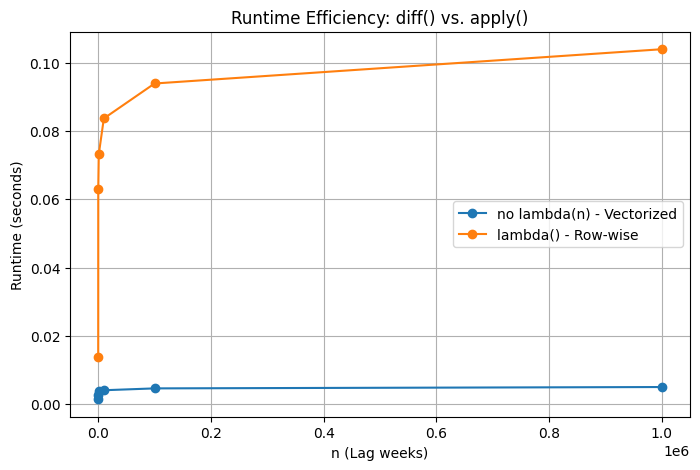

In [314]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt

# Generate a large dataset
size = 10000


# Define the row-wise function
def get_past_n_week_return(n, row):
    current_index = row.name
    past_index = current_index - n
    try: 
        ret = df.loc[current_index, "close"] - df.loc[past_index, "close"]
    except: 
        ret = np.nan
    return ret

# Test different values of n
n_values = [10, 100, 1000, 10000, 100000, 1000000]
no_lamb = []
lamb = []

test = df.copy(deep=True)
for n in n_values:
    # Measure time for diff()
    start = time.time()
    abs_avg_daily_return = test["rel_abs_daily_return"].abs().groupby(test["Year_Week"]).mean()
    try: 
        total_time = no_lamb[-1]+ (time.time()-start)
    except: 
        total_time = 0 + (time.time()-start)
    
    no_lamb.append(total_time)

    # Measure time for apply()
    start = time.time()
    abs_avg_daily_return = test.groupby("Year_Week")["rel_abs_daily_return"].apply(lambda x: x.abs().mean())
    try: 
        total_time = lamb[-1] + (time.time()-start)
    except: 
        total_time = 0 + (time.time()-start)
        
    lamb.append(total_time)

# Plot results
plt.figure(figsize=(8, 5))
plt.plot(n_values, no_lamb, marker="o", label="no lambda(n) - Vectorized")
plt.plot(n_values, lamb, marker="o", label="lambda() - Row-wise")
plt.xlabel("n (Lag weeks)")
plt.ylabel("Runtime (seconds)")
plt.title("Runtime Efficiency: diff() vs. apply()")
plt.legend()
plt.grid()
plt.show()
